In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [28]:
def apply_closing(img_th, disk_size):
    """
    Apply morphological closing (dilation followed by erosion) using OpenCV.

    Args:
        img_th: np.ndarray (M, N) - Binary image
        disk_size: int - Size of the structuring element

    Returns:
        np.ndarray (M, N): Image after closing
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
    img_closing = cv2.morphologyEx(img_th, cv2.MORPH_CLOSE, kernel)
    return img_closing


In [29]:
def apply_opening(img_th, disk_size):
    """
    Apply morphological opening (erosion followed by dilation) using OpenCV.

    Args:
        img_th: np.ndarray (M, N) - Binary image
        disk_size: int - Size of the structuring element

    Returns:
        np.ndarray (M, N): Image after opening
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
    img_opening = cv2.morphologyEx(img_th, cv2.MORPH_OPEN, kernel)
    return img_opening


In [30]:
def remove_holes(img_th, size):
    """
    Fill holes in a binary image that are smaller than a given size.

    Args:
        img_th: np.ndarray (M, N) - Binary image (0 and 255)
        size: int - Maximum size of holes to remove

    Returns:
        np.ndarray (M, N): Image with small holes filled
    """
    # Invert the image so holes become objects
    inv_img = cv2.bitwise_not(img_th)

    # Label connected components (holes)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(inv_img, connectivity=8)

    # Create a mask for holes to keep
    output = inv_img.copy()
    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area < size:
            output[labels == i] = 0  # Fill hole

    # Invert back to original polarity
    img_holes = cv2.bitwise_not(output)
    return img_holes


In [31]:
def remove_objects(img_th, size):
    """
    Remove objects (white regions) smaller than given size.

    Args:
        img_th: np.ndarray (M, N) - Binary image (0 and 255)
        size: int - Minimum size of objects to keep

    Returns:
        np.ndarray (M, N): Cleaned image
    """
    # Label connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(img_th, connectivity=8)

    output = np.zeros_like(img_th)
    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= size:
            output[labels == i] = 255  # Keep object
    return output


In [32]:
def apply_morphology(img_th):
    """
    Apply morphology to thresholded image

    Args
    ----
    img_th: np.ndarray (M, N)
        Image mask of size MxN.

    Return
    ------
    img_morph: np.ndarray (M, N)
        Image after morphological operations
    """

    img_morph = np.zeros_like(img_th)
    
    # ------------------
    img_morph = remove_objects(remove_holes(apply_opening(apply_closing(img_th, 2), 3), 100), 100)
    # ------------------
    
    return img_morph

In [37]:
img = cv2.imread(r'images\train\Amandina_JPG.rf.f68b5627f29c9a1f7c6284063f3ef4bc.jpg')

img_morph = apply_morphology(img)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_morph, cv2.COLOR_BGR2RGB))
plt.title('Morphological Image')
plt.axis('off')
plt.show()


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\connectedcomponents.cpp:5623: error: (-215:Assertion failed) L.channels() == 1 && I.channels() == 1 in function 'cv::connectedComponents_sub1'


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
# img = cv2.imread(r'images\train\Amandina_JPG.rf.f68b5627f29c9a1f7c6284063f3ef4bc.jpg')
img = cv2.imread(r'images\train\L1000826_JPG.rf.a372fc6f59a8e80a3da270e5186e58a2.jpg')
# img = cv2.imread(r'images\train\L1000780_JPG.rf.1cfecfde1b5d04b64aa295e9c884f82b.jpg')
if img is None:
    raise FileNotFoundError("Image not found — check the path.")

# Convert to grayscale and threshold
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, img_th = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

# Define morphological operations using OpenCV
def apply_closing(img_th, disk_size):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
    return cv2.morphologyEx(img_th, cv2.MORPH_CLOSE, kernel)

def apply_opening(img_th, disk_size):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
    return cv2.morphologyEx(img_th, cv2.MORPH_OPEN, kernel)

def remove_holes(img_th, size):
    inv = cv2.bitwise_not(img_th)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(inv, connectivity=8)
    cleaned = inv.copy()
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] < size:
            cleaned[labels == i] = 0
    return cv2.bitwise_not(cleaned)

def remove_objects(img_th, size):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(img_th, connectivity=8)
    cleaned = np.zeros_like(img_th)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= size:
            cleaned[labels == i] = 255
    return cleaned

# Your combined morphology function
def apply_morphology(img_th):
    img_morph = np.zeros_like(img_th)
    img_morph = remove_objects(
                    remove_holes(
                        apply_opening(
                            apply_closing(img_th, 2), 3),
                        100),
                    100)
    return img_morph

# Apply morphology
img_morph = apply_morphology(img_th)

# Show results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_th, cmap='gray')
plt.title("Initial Threshold (Inverted)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_morph, cmap='gray')
plt.title("After apply_morphology()")
plt.axis('off')
plt.show()



KeyboardInterrupt: 

In [2]:
def detect_edges(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
    return edges


In [8]:
def get_contours(edges):
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

In [22]:
def draw_contours(image, contours):
    output = image.copy()
    for cnt in contours:
        if cv2.contourArea(cnt) > 5000:  # ⬅ This is the minimum area filter
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return output


In [23]:
def segment_objects(image, contours):
    masks = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.drawContours(mask, [cnt], -1, 255, -1)
            masked = cv2.bitwise_and(image, image, mask=mask)
            masks.append(masked)
    return masks


In [45]:
def color_mask_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Chocolate-like color range (adjust as needed)
    lower = np.array([5, 50, 20])
    upper = np.array([30, 255, 255])
    
    mask = cv2.inRange(hsv, lower, upper)
    return mask


In [46]:
def get_filtered_contours(mask, min_area=1000):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = w / float(h)
        extent = area / (w * h)
        if 0.3 < aspect_ratio < 3.5 and extent > 0.3:
            filtered.append(c)
    return filtered

In [48]:
def bright_region_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Adaptive threshold to find brighter blobs (e.g., white chocolate)
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,  # block size
        -10  # subtractive constant (tune this)
    )


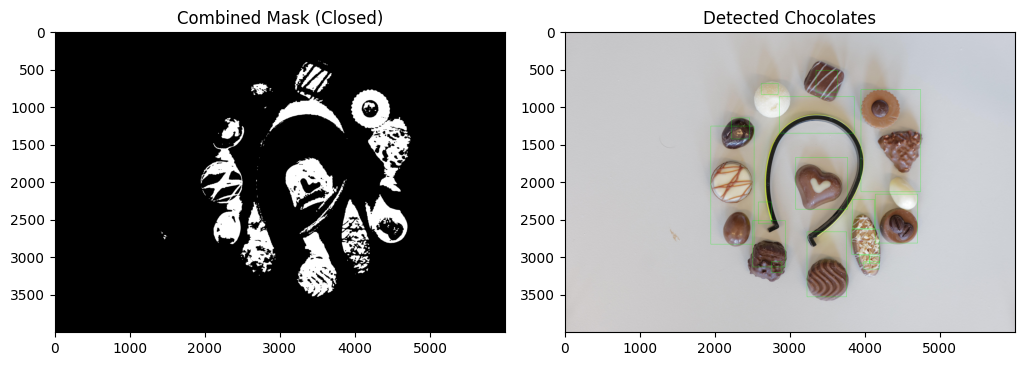

In [51]:
# img = cv2.imread(r'images\train\Amandina_JPG.rf.f68b5627f29c9a1f7c6284063f3ef4bc.jpg')
img = cv2.imread(r'images\train\L1000826_JPG.rf.a372fc6f59a8e80a3da270e5186e58a2.jpg')


# edges = detect_edges(img)



# --- Main Pipeline ---
edges = detect_edges(img)
color_mask = color_mask_hsv(img)

# Combine edge + color info
combined = cv2.bitwise_or(edges, color_mask)

bright_mask = bright_region_mask(img)
combined = cv2.bitwise_or(combined, bright_mask)


# Morphological closing to join fragmented regions
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
# closed = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)

# First: opening removes thin shadows
opening_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
opened = cv2.morphologyEx(combined, cv2.MORPH_OPEN, opening_kernel)

# Then: closing connects actual chocolate blobs
closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, closing_kernel)


# Get final contours
contours = get_filtered_contours(closed, min_area=1500)

# Draw results
boxed = draw_contours(img, contours)

# --- Plot ---
plt.figure(figsize=(15, 5))
# plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(closed, cmap='gray'); plt.title("Combined Mask (Closed)")
plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)); plt.title("Detected Chocolates")
plt.tight_layout()
plt.show()



# # NEW: Morphological closing to group fragmented edges
# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
# closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# color_mask = color_mask_hsv(img)
# combined = cv2.bitwise_or(closed_edges, color_mask)

# closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# contours = get_contours(closed)  # Use closed instead of edges

# boxed = draw_contours(img, contours)  # Keep area filter, increase threshold


# plt.figure(figsize=(15,5))
# # plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
# # plt.subplot(1,3,2); plt.imshow(edges, cmap='gray'); plt.title("Edges")
# plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)); plt.title("Bounding Boxes")
